## 下载库

In [18]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost optuna shap joblib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\86137\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


## 导入必要的库

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 机器学习库
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# 高级模型
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# 调参与解释
import optuna
import shap

# 可视化设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
sns.set_palette("husl")

print("✅ 所有库已导入")

✅ 所有库已导入


## 加载数据

In [3]:
train_df = pd.read_csv('PVA_hydrogel_train.csv')
val_df = pd.read_csv('PVA_hydrogel_val.csv')
test_df = pd.read_csv('PVA_hydrogel_test.csv')

print(f"训练集形状: {train_df.shape}")
print(f"验证集形状: {val_df.shape}")
print(f"测试集形状: {test_df.shape}")

print("\n📊 训练集基本信息:")
print(train_df.info())
print("\n📈 训练集描述性统计:")
print(train_df.describe())

训练集形状: (280, 25)
验证集形状: (80, 25)
测试集形状: (40, 25)

📊 训练集基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   No              280 non-null    int64  
 1   PVA_MW          280 non-null    float64
 2   PVA_DH          263 non-null    float64
 3   PVA_Conc        268 non-null    float64
 4   FC              280 non-null    int64  
 5   CLM             280 non-null    int64  
 6   CC              265 non-null    float64
 7   Borax           280 non-null    int64  
 8   CaCl2           280 non-null    int64  
 9   EG              280 non-null    int64  
 10  GL              280 non-null    int64  
 11  MBA             280 non-null    int64  
 12  PBA             280 non-null    int64  
 13  AgNPs           280 non-null    int64  
 14  CNF             280 non-null    int64  
 15  CNT             280 non-null    int64  
 16  Ionic_only      280

## EDA（探索性数据分析）

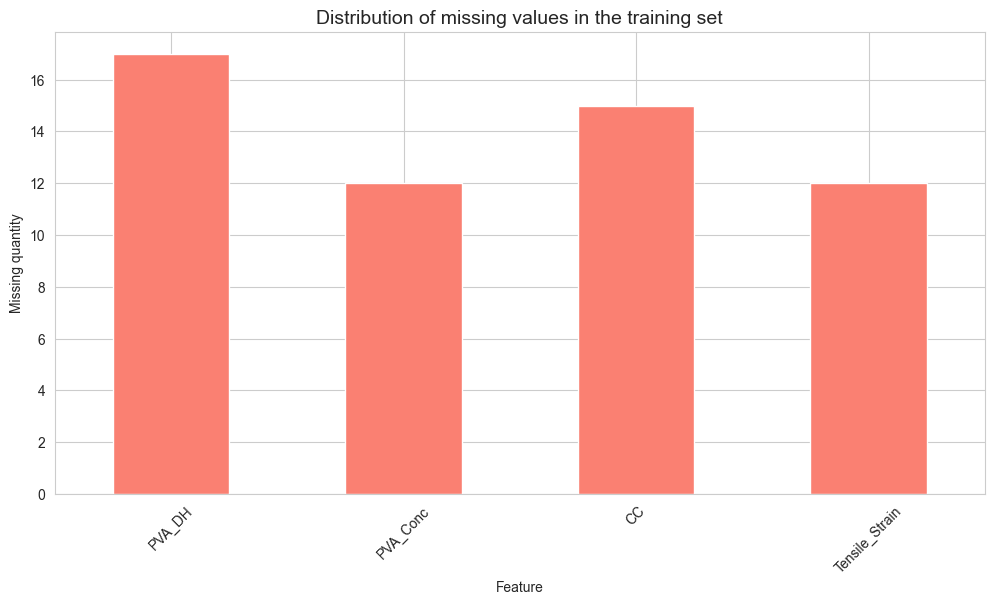

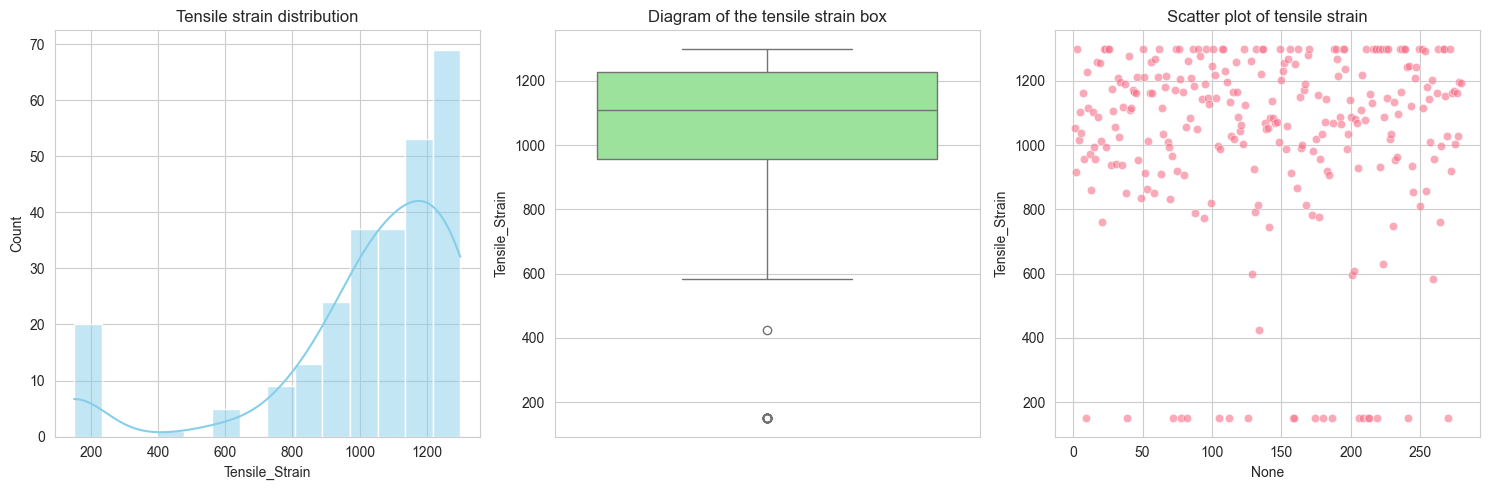

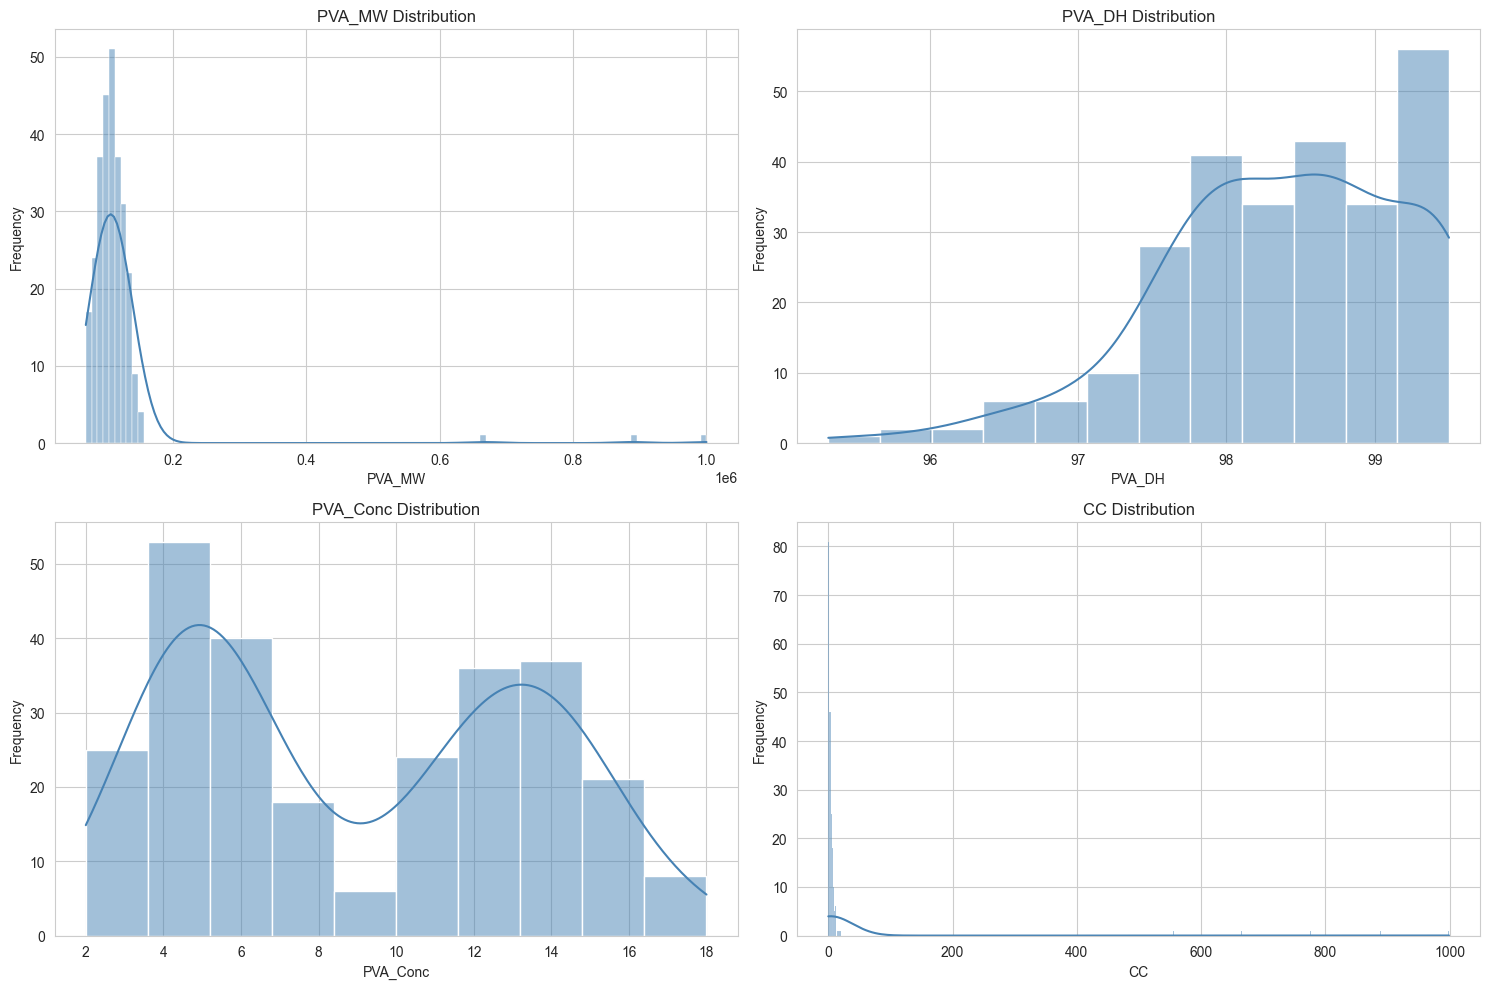

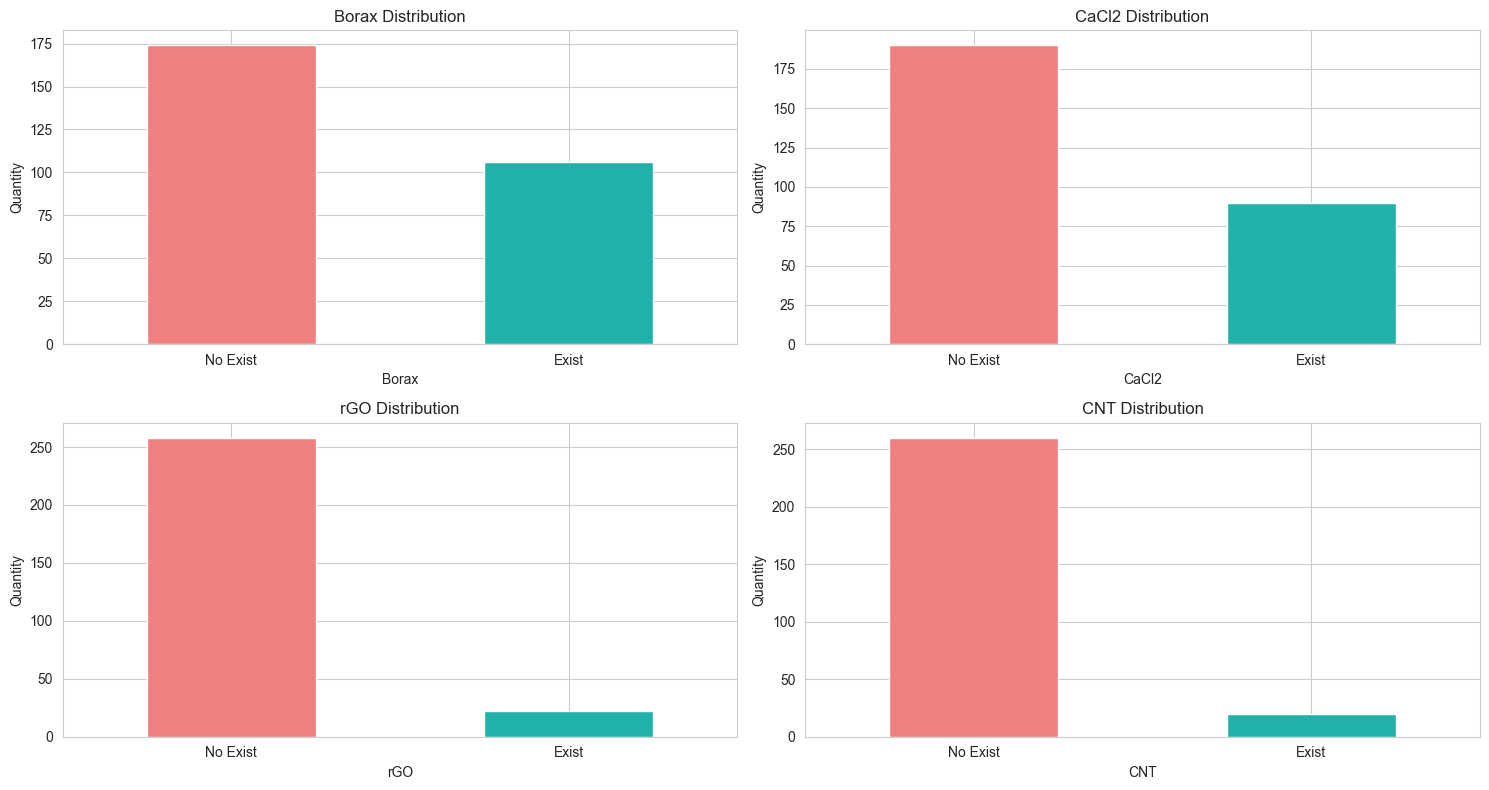

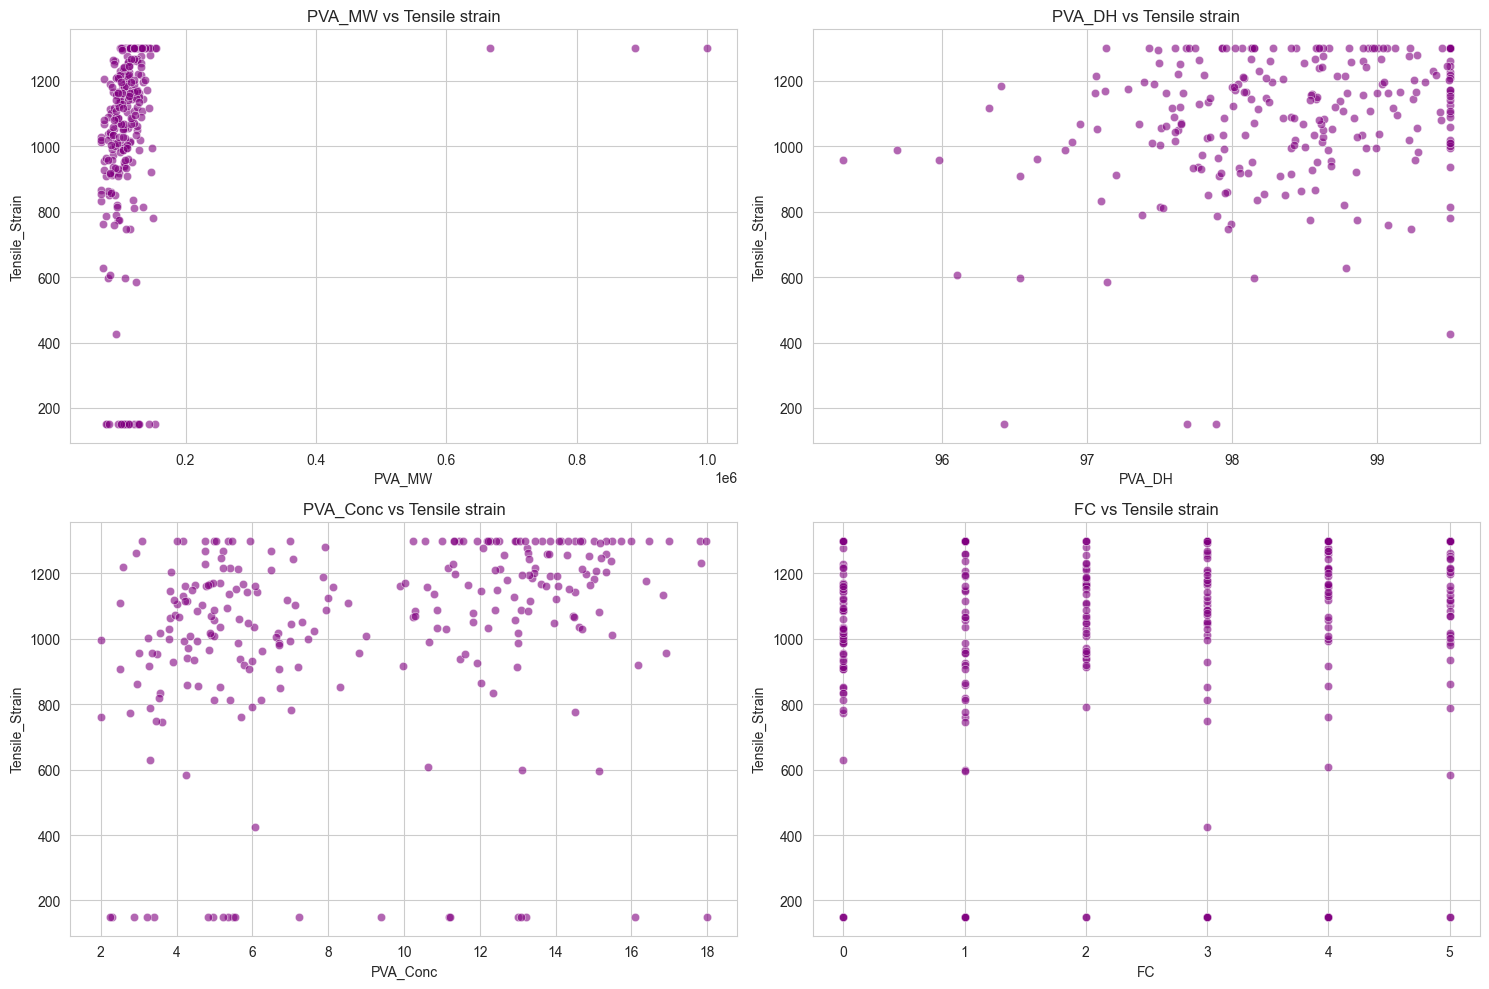

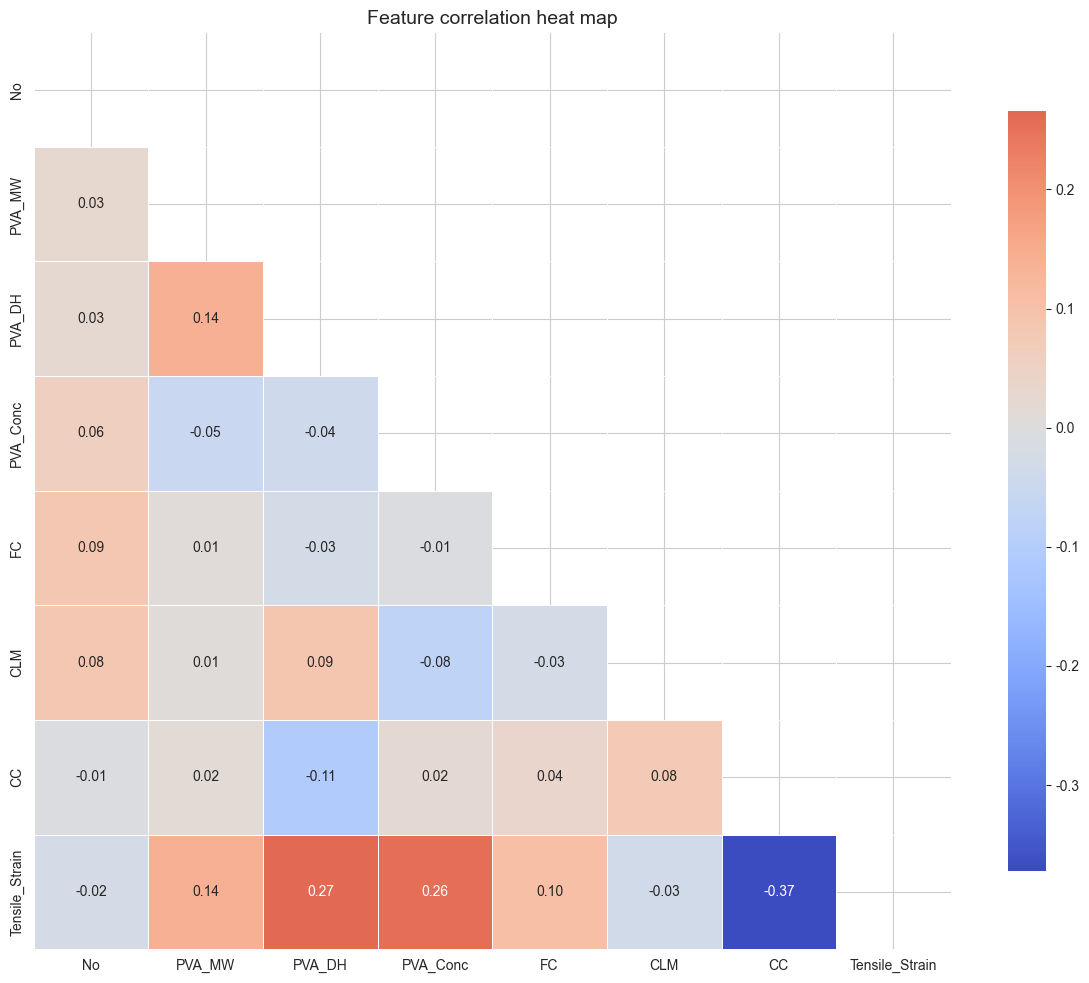

In [4]:
# 3.1 缺失值分析
plt.figure(figsize=(12, 6))
missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if len(missing_values) > 0:
    missing_values.plot(kind='bar', color='salmon')
    plt.title('Distribution of missing values in the training set', fontsize=14)
    plt.ylabel('Missing quantity')
    plt.xlabel('Feature')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("✅ 训练集无缺失值")
    
# 3.2 目标变量分布
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(train_df['Tensile_Strain'], kde=True, color='skyblue')
plt.title('Tensile strain distribution')

plt.subplot(1, 3, 2)
sns.boxplot(y=train_df['Tensile_Strain'], color='lightgreen')
plt.title('Diagram of the tensile strain box')

plt.subplot(1, 3, 3)
sns.scatterplot(x=train_df.index, y=train_df['Tensile_Strain'], alpha=0.6)
plt.title('Scatter plot of tensile strain')

plt.tight_layout()
plt.show()

# 3.3 关键连续特征分布
continuous_features = ['PVA_MW', 'PVA_DH', 'PVA_Conc', 'CC']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(continuous_features):
    if feature in train_df.columns:
        sns.histplot(train_df[feature], kde=True, ax=axes[idx], color='steelblue')
        axes[idx].set_title(f'{feature} Distribution', fontsize=12)
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 3.4 二元特征分布
binary_features = ['Borax', 'CaCl2', 'rGO', 'CNT']  # 选择几个重要的
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.ravel()

for idx, feature in enumerate(binary_features):
    if feature in train_df.columns:
        train_df[feature].value_counts().plot(kind='bar', ax=axes[idx], color=['lightcoral', 'lightseagreen'])
        axes[idx].set_title(f'{feature} Distribution', fontsize=12)
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Quantity')
        axes[idx].set_xticklabels(['No Exist', 'Exist'], rotation=0)

plt.tight_layout()
plt.show()

# 3.5 特征与目标变量关系
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

top_features = ['PVA_MW', 'PVA_DH', 'PVA_Conc', 'FC']
for idx, feature in enumerate(top_features):
    if feature in train_df.columns:
        sns.scatterplot(x=train_df[feature], y=train_df['Tensile_Strain'], 
                       alpha=0.6, ax=axes[idx], color='purple')
        axes[idx].set_title(f'{feature} vs Tensile strain', fontsize=12)
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Tensile_Strain')
        
        # 添加趋势线
        try:
            z = np.polyfit(train_df[feature].fillna(train_df[feature].median()), 
                          train_df['Tensile_Strain'], 1)
            p = np.poly1d(z)
            axes[idx].plot(train_df[feature].sort_values(), 
                          p(train_df[feature].sort_values()), 
                          "r--", alpha=0.8, linewidth=2)
        except:
            pass

plt.tight_layout()
plt.show()

# 3.6 相关性热力图
plt.figure(figsize=(12, 10))
# 选择数值特征计算相关性
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
# 排除二元特征，专注于连续特征
numeric_cols = [col for col in numeric_cols if train_df[col].nunique() > 2]

if len(numeric_cols) > 1:
    corr_matrix = train_df[numeric_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Feature correlation heat map', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # 高相关性特征对
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.5 and i != j:
                high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
    
    if high_corr_pairs:
        print("🔍 高相关性特征对 (|r| > 0.5):")
        for pair in high_corr_pairs[:10]:  # 只显示前10对
            print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")

## 数据预处理

In [5]:
def preprocess_pva_data(train_df, val_df, test_df, target_col='Tensile_Strain'):
    """
    预处理PVA水凝胶数据集
    """
    print("🔄 开始数据预处理...")
    
    # 创建副本
    train_processed = train_df.copy()
    val_processed = val_df.copy()
    test_processed = test_df.copy()
    
    # 4.1 处理PVA_Conc格式问题（处理'约X%'格式）
    def clean_concentration(value):
        if isinstance(value, str):
            cleaned = str(value).replace('约', '').replace('%', '')
            try:
                return float(cleaned)
            except:
                return np.nan
        return value
    
    for df in [train_processed, val_processed, test_processed]:
        df['PVA_Conc'] = df['PVA_Conc'].apply(clean_concentration)
    
    # 4.2 处理异常值
    # 定义合理范围
    reasonable_ranges = {
        'PVA_MW': (70000, 160000),
        'PVA_DH': (95, 99.5),
        'PVA_Conc': (2, 18),
        'CC': (0, 20),
        'FC': (0, 5)
    }
    
    for col, (min_val, max_val) in reasonable_ranges.items():
        if col in train_processed.columns:
            # 将超出范围的值设为NaN
            train_processed.loc[~train_processed[col].between(min_val, max_val), col] = np.nan
            val_processed.loc[~val_processed[col].between(min_val, max_val), col] = np.nan
            test_processed.loc[~test_processed[col].between(min_val, max_val), col] = np.nan
    
    # 4.3 分离特征和目标
    X_train = train_processed.drop(columns=[target_col])
    y_train = train_processed[target_col]
    
    X_val = val_processed.drop(columns=[target_col])
    y_val = val_processed[target_col]
    
    X_test = test_processed.drop(columns=[target_col])
    y_test = test_processed[target_col]
    
    # 4.4 缺失值处理
    # 数值特征用中位数填充
    numeric_cols = ['PVA_MW', 'PVA_DH', 'PVA_Conc', 'CC']
    for col in numeric_cols:
        if col in X_train.columns:
            median_val = X_train[col].median()
            # 填充训练集
            if X_train[col].isnull().any():
                X_train[col].fillna(median_val, inplace=True)
            # 用相同的值填充验证集和测试集
            if X_val[col].isnull().any():
                X_val[col].fillna(median_val, inplace=True)
            if X_test[col].isnull().any():
                X_test[col].fillna(median_val, inplace=True)
    
    # 离散特征用众数填充
    discrete_cols = ['FC', 'CLM']
    for col in discrete_cols:
        if col in X_train.columns:
            # 计算训练集众数
            mode_val = X_train[col].mode()
            fill_val = mode_val[0] if not mode_val.empty else 0
            # 填充训练集
            if X_train[col].isnull().any():
                X_train[col].fillna(fill_val, inplace=True)
            # 用相同的值填充验证集和测试集
            if X_val[col].isnull().any():
                X_val[col].fillna(fill_val, inplace=True)
            if X_test[col].isnull().any():
                X_test[col].fillna(fill_val, inplace=True)
    
    # 4.5 特征编码
    # CLM如果是无序类别，进行独热编码
    if 'CLM' in X_train.columns:
        # 保存原始列名
        original_columns = X_train.columns.tolist()
        
        # 独热编码
        X_train = pd.get_dummies(X_train, columns=['CLM'], prefix='CLM')
        X_val = pd.get_dummies(X_val, columns=['CLM'], prefix='CLM')
        X_test = pd.get_dummies(X_test, columns=['CLM'], prefix='CLM')
        
        # 确保所有数据集有相同的列
        all_columns = set(X_train.columns) | set(X_val.columns) | set(X_test.columns)
        for df in [X_train, X_val, X_test]:
            for col in all_columns:
                if col not in df.columns:
                    df[col] = 0
        
        # 按训练集的列顺序排序
        X_train = X_train.reindex(sorted(X_train.columns), axis=1)
        X_val = X_val.reindex(sorted(X_train.columns), axis=1)
        X_test = X_test.reindex(sorted(X_train.columns), axis=1)
    
    # 4.6 特征工程
    print("  🔧 进行特征工程...")
    
    # 比例特征
    X_train['MW_Conc_Ratio'] = X_train['PVA_MW'] / (X_train['PVA_Conc'] + 1e-5)
    X_val['MW_Conc_Ratio'] = X_val['PVA_MW'] / (X_val['PVA_Conc'] + 1e-5)
    X_test['MW_Conc_Ratio'] = X_test['PVA_MW'] / (X_test['PVA_Conc'] + 1e-5)
    
    X_train['MW_DH_Product'] = X_train['PVA_MW'] * X_train['PVA_DH']
    X_val['MW_DH_Product'] = X_val['PVA_MW'] * X_val['PVA_DH']
    X_test['MW_DH_Product'] = X_test['PVA_MW'] * X_test['PVA_DH']
    
    # 交互特征
    X_train['MW_FC_Interaction'] = X_train['PVA_MW'] * X_train['FC']
    X_val['MW_FC_Interaction'] = X_val['PVA_MW'] * X_val['FC']
    X_test['MW_FC_Interaction'] = X_test['PVA_MW'] * X_test['FC']
    
    X_train['Conc_CC_Interaction'] = X_train['PVA_Conc'] * X_train['CC']
    X_val['Conc_CC_Interaction'] = X_val['PVA_Conc'] * X_val['CC']
    X_test['Conc_CC_Interaction'] = X_test['PVA_Conc'] * X_test['CC']
    
    # 多项式特征（简单的平方项）
    X_train['PVA_MW_squared'] = X_train['PVA_MW'] ** 2
    X_val['PVA_MW_squared'] = X_val['PVA_MW'] ** 2
    X_test['PVA_MW_squared'] = X_test['PVA_MW'] ** 2
    
    X_train['PVA_Conc_squared'] = X_train['PVA_Conc'] ** 2
    X_val['PVA_Conc_squared'] = X_val['PVA_Conc'] ** 2
    X_test['PVA_Conc_squared'] = X_test['PVA_Conc'] ** 2
    
    # 对数变换（处理偏态分布）
    skewed_cols = ['PVA_MW', 'CC']
    for col in skewed_cols:
        if col in X_train.columns:
            X_train[f'log_{col}'] = np.log1p(X_train[col])
            X_val[f'log_{col}'] = np.log1p(X_val[col])
            X_test[f'log_{col}'] = np.log1p(X_test[col])
    
    # 4.7 特征缩放（可选，对某些模型重要）
    # 这里我们创建缩放版本，但保持原始版本
    scaler = StandardScaler()
    scaled_features = ['PVA_MW', 'PVA_DH', 'PVA_Conc', 'CC', 'FC']
    
    scaled_cols = [col for col in scaled_features if col in X_train.columns]
    if scaled_cols:
        X_train_scaled = X_train.copy()
        X_val_scaled = X_val.copy()
        X_test_scaled = X_test.copy()
        
        X_train_scaled[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
        X_val_scaled[scaled_cols] = scaler.transform(X_val[scaled_cols])
        X_test_scaled[scaled_cols] = scaler.transform(X_test[scaled_cols])
    else:
        X_train_scaled, X_val_scaled, X_test_scaled = X_train.copy(), X_val.copy(), X_test.copy()
    
    print(f"  ✅ 预处理完成")
    print(f"    训练集特征数: {X_train.shape[1]}")
    print(f"    验证集特征数: {X_val.shape[1]}")
    print(f"    测试集特征数: {X_test.shape[1]}")
    
    return {
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test,
        'X_train_scaled': X_train_scaled,
        'X_val_scaled': X_val_scaled,
        'X_test_scaled': X_test_scaled,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'feature_names': X_train.columns.tolist()
    }

# 运行预处理
data_dict = preprocess_pva_data(train_df, val_df, test_df, target_col='Tensile_Strain')

🔄 开始数据预处理...
  🔧 进行特征工程...
  ✅ 预处理完成
    训练集特征数: 37
    验证集特征数: 37
    测试集特征数: 37


In [6]:
# ========== 处理训练集 ==========
data_dict = preprocess_pva_data(train_df, val_df, test_df, target_col='Tensile_Strain') 
X_train = data_dict['X_train']
y_train = data_dict['y_train']
X_val = data_dict['X_val']
y_val = data_dict['y_val']
# 筛选出y_train非NaN的样本索引
train_valid_idx = y_train.notna()
# 同步过滤X_train和y_train
X_train_clean = X_train[train_valid_idx].copy()
y_train_clean = y_train[train_valid_idx].copy()

# ========== 处理验证集 ==========
# 筛选出y_val非NaN的样本索引
val_valid_idx = y_val.notna()
# 同步过滤X_val和y_val
X_val_clean = X_val[val_valid_idx].copy()
y_val_clean = y_val[val_valid_idx].copy()

# 验证处理结果
print("=== 处理后结果 ===")
print(f"X_train_clean 样本数：{len(X_train_clean)}, y_train_clean 样本数：{len(y_train_clean)}")
print(f"X_val_clean 样本数：{len(X_val_clean)}, y_val_clean 样本数：{len(y_val_clean)}")
print(f"y_train_clean 缺失值：{y_train_clean.isnull().sum()}, y_val_clean 缺失值：{y_val_clean.isnull().sum()}")

🔄 开始数据预处理...
  🔧 进行特征工程...
  ✅ 预处理完成
    训练集特征数: 37
    验证集特征数: 37
    测试集特征数: 37
=== 处理后结果 ===
X_train_clean 样本数：268, y_train_clean 样本数：268
X_val_clean 样本数：72, y_val_clean 样本数：72
y_train_clean 缺失值：0, y_val_clean 缺失值：0


In [7]:
import re

def check_special_chars(col_name):
    """检查特征名是否包含特殊字符（非字母、数字、下划线）"""
    # 匹配任何非字母、非数字、非下划线的字符
    special_chars = re.findall(r'[^a-zA-Z0-9_]', str(col_name))
    # 如果找到特殊字符，返回True；否则返回False
    return len(special_chars) > 0
    
def clean_feature_name(col_name):
    """清理特征名：
    1. 移除/替换特殊字符为下划线
    2. 中文替换为拼音/简写（或直接用feature_数字）
    3. 确保列名唯一
    """
    # 步骤1：将非字母数字的字符替换为下划线
    clean_name = re.sub(r'[^a-zA-Z0-9_]', '_', str(col_name))
    # 步骤2：移除连续的下划线（比如"feat__1"→"feat_1"）
    clean_name = re.sub(r'_+', '_', clean_name)
    # 步骤3：移除开头/结尾的下划线（比如"_feat1_"→"feat1"）
    clean_name = clean_name.strip('_')
    # 步骤4：如果为空，命名为feature_默认值
    if clean_name == '':
        clean_name = 'feature_empty'
    return clean_name

# 生成新的特征名映射（原列名→清理后的列名）
new_col_names = {col: clean_feature_name(col) for col in X_train_clean.columns}
# 确保列名唯一（避免重复）
unique_new_names = []
count = 1
for col in X_train_clean.columns:
    base_name = new_col_names[col]
    while base_name in unique_new_names:
        base_name = f"{new_col_names[col]}_{count}"
        count += 1
    unique_new_names.append(base_name)
new_col_names = dict(zip(X_train_clean.columns, unique_new_names))

# 重命名X_train_clean和X_val_clean的列
X_train_clean = X_train_clean.rename(columns=new_col_names)
X_val_clean = X_val_clean.rename(columns=new_col_names)

# 验证清理结果
print("清理后的特征名前10个：", list(X_train_clean.columns)[:10])
print("是否还有特殊字符：", any(check_special_chars(col) for col in X_train_clean.columns))  # 应输出False

清理后的特征名前10个： ['AgNPs', 'Borax', 'CC', 'CLM_0', 'CLM_1', 'CLM_2', 'CLM_3', 'CLM_4', 'CLM_5', 'CNF']
是否还有特殊字符： False


## 多模型训练与比较

🚀 开始多模型训练与比较...
  训练 Linear regression...
  训练 Ling Hui GUI...
  训练 Lasso Return...
  训练 Decision tree...
  训练 Random Forest...
  训练 Gradient boosting...
  训练 K-nearest neighbor...
  训练 Support vector regression...
  训练 XGBoost...
  训练 LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000597 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1174
[LightGBM] [Info] Number of data points in the train set: 268, number of used features: 36
[LightGBM] [Info] Start training from score 1028.812661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

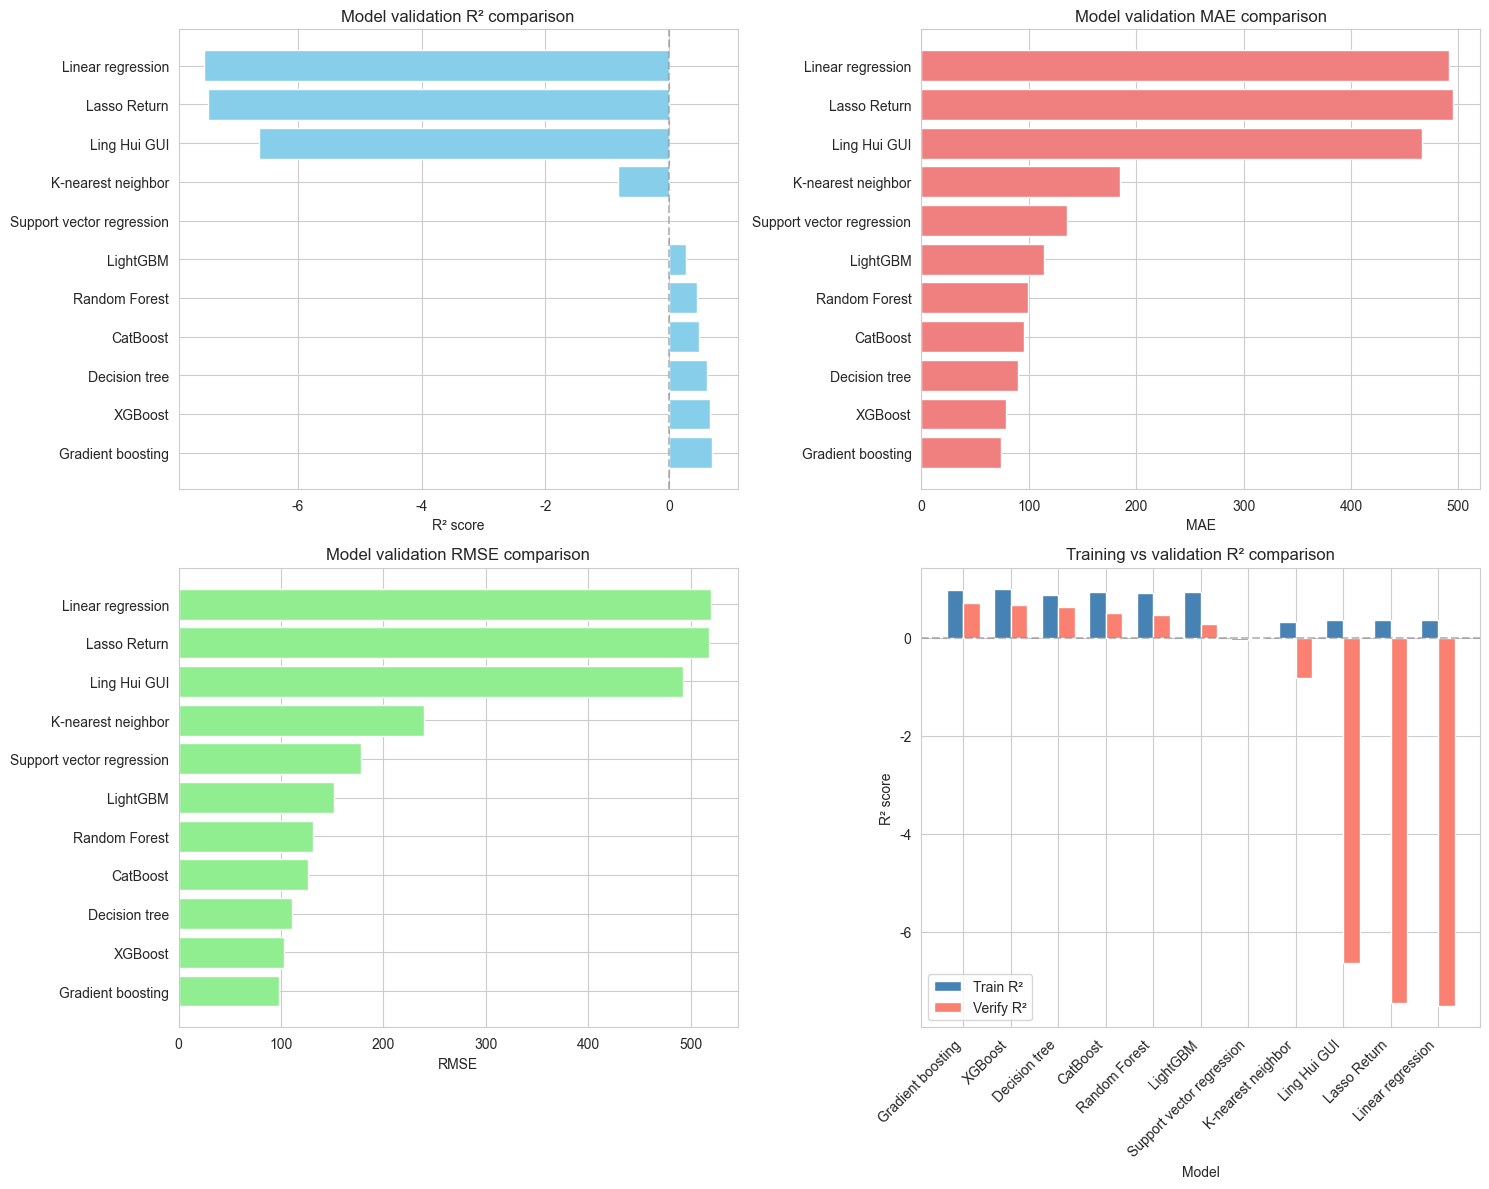


🏆 最佳模型: Gradient boosting
   验证R²: 0.6999
   验证MAE: 74.61
   验证RMSE: 97.58


In [8]:
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    """评估单个模型"""
    # 训练
    model.fit(X_train, y_train)
    
    # 预测
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # 计算指标
    metrics = {
        '模型': model_name,
        '训练R²': r2_score(y_train, y_train_pred),
        '验证R²': r2_score(y_val, y_val_pred),
        '训练MAE': mean_absolute_error(y_train, y_train_pred),
        '验证MAE': mean_absolute_error(y_val, y_val_pred),
        '训练RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        '验证RMSE': np.sqrt(mean_squared_error(y_val, y_val_pred))
    }
    
    return metrics, model, y_val_pred

print("🚀 开始多模型训练与比较...")

# 定义模型列表
models = {
    'Linear regression': LinearRegression(),
    'Ling Hui GUI': Ridge(alpha=1.0, random_state=42),
    'Lasso Return': Lasso(alpha=0.1, random_state=42),
    'Decision tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Gradient boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'K-nearest neighbor': KNeighborsRegressor(n_neighbors=5),
    'Support vector regression': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'CatBoost': cb.CatBoostRegressor(iterations=100, learning_rate=0.1, depth=5, 
                                     verbose=False, random_state=42)
}

# 评估所有模型（使用处理后的干净数据）
results = []
trained_models = {}
val_predictions = {}

for name, model in models.items():
    print(f"  训练 {name}...")
    metrics, trained_model, y_val_pred = evaluate_model(
        model, X_train_clean, y_train_clean, X_val_clean, y_val_clean, name
    )
    results.append(metrics)
    trained_models[name] = trained_model
    val_predictions[name] = y_val_pred

# 创建结果DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('验证R²', ascending=False)
results_df = results_df.reset_index(drop=True)

print("\n📊 模型性能比较:")
print(results_df.to_string(index=False))

# 可视化模型比较
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. R²比较
axes[0, 0].barh(results_df['模型'], results_df['验证R²'], color='skyblue')
axes[0, 0].set_xlabel('R² score')
axes[0, 0].set_title('Model validation R² comparison')
axes[0, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# 2. MAE比较
axes[0, 1].barh(results_df['模型'], results_df['验证MAE'], color='lightcoral')
axes[0, 1].set_xlabel('MAE')
axes[0, 1].set_title('Model validation MAE comparison')

# 3. RMSE比较
axes[1, 0].barh(results_df['模型'], results_df['验证RMSE'], color='lightgreen')
axes[1, 0].set_xlabel('RMSE')
axes[1, 0].set_title('Model validation RMSE comparison')  

# 4. 训练vs验证R²
x = np.arange(len(results_df))
width = 0.35
axes[1, 1].bar(x - width/2, results_df['训练R²'], width, label='Train R²', color='steelblue')
axes[1, 1].bar(x + width/2, results_df['验证R²'], width, label='Verify R²', color='salmon')
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('R² score')
axes[1, 1].set_title('Training vs validation R² comparison')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(results_df['模型'], rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 选择最佳模型
best_model_name = results_df.iloc[0]['模型']
best_model = trained_models[best_model_name]
print(f"\n🏆 最佳模型: {best_model_name}")
print(f"   验证R²: {results_df.iloc[0]['验证R²']:.4f}")
print(f"   验证MAE: {results_df.iloc[0]['验证MAE']:.2f}")
print(f"   验证RMSE: {results_df.iloc[0]['验证RMSE']:.2f}")

## 贝叶斯优化调参

In [9]:
# 检查索引是否一致（样本数匹配的核心是索引一致）
print(f"\nX_train_clean 与 y_train_clean 索引是否一致：{X_train_clean.index.equals(y_train_clean.index)}")
print(f"X_val_clean 与 y_val_clean 索引是否一致：{X_val_clean.index.equals(y_val_clean.index)}")
# ========== 重新同步处理训练集 ==========
# 1. 基于 y_train 的非 NaN 索引，生成统一的掩码（核心：以 y 为基准）
train_mask = data_dict['y_train'].notna()  # 基于原始y_train的非NaN掩码
# 2. 同步筛选 X_train 和 y_train（用同一个掩码）
X_train_clean = data_dict['X_train'][train_mask].copy()
y_train_clean = data_dict['y_train'][train_mask].copy()

# ========== 重新同步处理验证集 ==========
val_mask = data_dict['y_val'].notna()  # 基于原始y_val的非NaN掩码
X_val_clean = data_dict['X_val'][val_mask].copy()
y_val_clean = data_dict['y_val'][val_mask].copy()

# ========== 再次清理特征名（避免特殊字符） ==========
import re
def clean_feature_name(col_name):
    clean_name = re.sub(r'[^a-zA-Z0-9_]', '_', str(col_name))
    clean_name = re.sub(r'_+', '_', clean_name).strip('_')
    return clean_name if clean_name else 'feature_empty'

# 确保特征名唯一且无特殊字符
new_cols = [clean_feature_name(col) for col in X_train_clean.columns]
unique_cols = []
count = 1
for col in new_cols:
    temp_col = col
    while temp_col in unique_cols:
        temp_col = f"{col}_{count}"
        count += 1
    unique_cols.append(temp_col)

X_train_clean.columns = unique_cols
X_val_clean.columns = unique_cols  # 验证集必须和训练集列名完全一致

# ========== 验证同步结果 ==========
print("=== 同步后样本数 ===")
print(f"X_train_clean 样本数：{len(X_train_clean)}, y_train_clean 样本数：{len(y_train_clean)}")
print(f"X_val_clean 样本数：{len(X_val_clean)}, y_val_clean 样本数：{len(y_val_clean)}")
print(f"训练集 X/y 样本数是否一致：{len(X_train_clean) == len(y_train_clean)}")  # 必须为True
print(f"验证集 X/y 样本数是否一致：{len(X_val_clean) == len(y_val_clean)}")    # 必须为True


X_train_clean 与 y_train_clean 索引是否一致：True
X_val_clean 与 y_val_clean 索引是否一致：True
=== 同步后样本数 ===
X_train_clean 样本数：268, y_train_clean 样本数：268
X_val_clean 样本数：72, y_val_clean 样本数：72
训练集 X/y 样本数是否一致：True
验证集 X/y 样本数是否一致：True


In [11]:
print("best_model_name 的实际值是：", best_model_name)

best_model_name 的实际值是： Gradient boosting


In [13]:
print(f"🔧 对最佳模型 {best_model_name} 进行贝叶斯优化调参（同步样本后）...")

# 根据最佳模型类型选择不同的调参空间
def get_trial_params(trial, model_type):
    """根据模型类型返回超参数"""
    if model_type == 'XGBoost':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
            'reg_lambda': trial.suggest_float('reg_lambda', 0, 1)
        }
    elif model_type == 'LightGBM':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
            'reg_lambda': trial.suggest_float('reg_lambda', 0, 1)
        }
    elif model_type == '随机森林':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        }
    elif model_type == '梯度提升':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
        }
    else:
        return {}

def objective(trial):
    """Optuna优化目标函数（使用同步后的干净数据）"""
    # 确定模型类型
    if 'XGB' in best_model_name or 'XGBoost' in best_model_name:
        model_type = 'XGBoost'
    elif 'LightGBM' in best_model_name or 'LGBM' in best_model_name:
        model_type = 'LightGBM'
    elif '随机森林' in best_model_name or 'RandomForest' in best_model_name:
        model_type = '随机森林'
    elif '梯度提升' in best_model_name or 'Gradient' in best_model_name or 'gradient' in best_model_name or 'boosting' in best_model_name:
        model_type = '梯度提升'
    else:
        return results_df.iloc[0]['验证R²']
    
    # 获取超参数
    params = get_trial_params(trial, model_type)
    
    # 创建模型
    if model_type == 'XGBoost':
        model = xgb.XGBRegressor(**params, random_state=42)
    elif model_type == 'LightGBM':
        model = lgb.LGBMRegressor(**params, random_state=42)
    elif model_type == '随机森林':
        model = RandomForestRegressor(**params, random_state=42)
    elif model_type == '梯度提升':
        model = GradientBoostingRegressor(**params, random_state=42)
    
    # 核心：使用样本数一致的干净数据训练/验证
    model.fit(X_train_clean, y_train_clean)
    y_val_pred = model.predict(X_val_clean)
    r2 = r2_score(y_val_clean, y_val_pred)
    
    return r2

# 运行贝叶斯优化（核心修改：精准匹配 "Gradient boosting"）
if any(keyword in best_model_name for keyword in ['XGBoost', 'LightGBM', '随机森林', '梯度提升', 'XGB', 'LGBM', 'RandomForest', 'Gradient', 'gradient', 'boosting']):
    # 创建优化研究对象
    study = optuna.create_study(direction='maximize', study_name=f"{best_model_name}_optimization")
    # 运行30次试验，显示进度条
    study.optimize(objective, n_trials=30, show_progress_bar=True)
    
    print(f"\n✅ 贝叶斯优化完成")
    print(f"   最佳验证R²: {study.best_value:.4f}")
    print(f"   最佳超参数: {study.best_params}")
    
    # 用最佳参数重新训练模型（核心修改：精准匹配 "Gradient boosting"）
    if 'XGB' in best_model_name or 'XGBoost' in best_model_name:
        optimized_model = xgb.XGBRegressor(**study.best_params, random_state=42)
    elif 'LightGBM' in best_model_name or 'LGBM' in best_model_name:
        optimized_model = lgb.LGBMRegressor(**study.best_params, random_state=42)
    elif '随机森林' in best_model_name or 'RandomForest' in best_model_name:
        optimized_model = RandomForestRegressor(**study.best_params, random_state=42)
    elif '梯度提升' in best_model_name or 'Gradient' in best_model_name or 'gradient' in best_model_name or 'boosting' in best_model_name:
        optimized_model = GradientBoostingRegressor(**study.best_params, random_state=42)
    
    # 训练最终优化模型
    optimized_model.fit(X_train_clean, y_train_clean)
    
    # 评估优化后模型
    y_val_pred_optimized = optimized_model.predict(X_val_clean)
    optimized_r2 = r2_score(y_val_clean, y_val_pred_optimized)
    optimized_mae = mean_absolute_error(y_val_clean, y_val_pred_optimized)
    optimized_rmse = np.sqrt(mean_squared_error(y_val_clean, y_val_pred_optimized))
    
    print(f"\n📊 优化后模型性能:")
    print(f"   验证R²: {optimized_r2:.4f}")
    print(f"   验证MAE: {optimized_mae:.2f}")
    print(f"   验证RMSE: {optimized_rmse:.2f}")
    
    # 与原始模型比较
    original_r2 = results_df.iloc[0]['验证R²']
    improvement = optimized_r2 - original_r2
    print(f"   原始验证R²: {original_r2:.4f}")
    print(f"   R²提升: {improvement:.4f}")
    
    best_model = optimized_model
else:
    print(f"⚠️  {best_model_name} 不支持自动调参，使用默认参数")

[I 2026-02-20 10:59:01,714] A new study created in memory with name: Gradient boosting_optimization


🔧 对最佳模型 Gradient boosting 进行贝叶斯优化调参（同步样本后）...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-02-20 10:59:02,160] Trial 0 finished with value: 0.5592036833297935 and parameters: {'n_estimators': 162, 'max_depth': 7, 'learning_rate': 0.0134112035167905, 'subsample': 0.9366418424803116, 'min_samples_split': 14, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.5592036833297935.
[I 2026-02-20 10:59:02,602] Trial 1 finished with value: 0.5048397514732159 and parameters: {'n_estimators': 270, 'max_depth': 4, 'learning_rate': 0.26422543767597056, 'subsample': 0.9282292765040924, 'min_samples_split': 15, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.5592036833297935.
[I 2026-02-20 10:59:03,115] Trial 2 finished with value: 0.6459681238005676 and parameters: {'n_estimators': 298, 'max_depth': 10, 'learning_rate': 0.013922246796413304, 'subsample': 0.6756079718869187, 'min_samples_split': 19, 'min_samples_leaf': 5}. Best is trial 2 with value: 0.6459681238005676.
[I 2026-02-20 10:59:03,344] Trial 3 finished with value: 0.48852928595971623 and parameters: {'n_estimato

## 模型解释（SHAP分析）


🔍 对最佳模型进行SHAP分析...
  正在计算SHAP值...
  绘制特征重要性图...


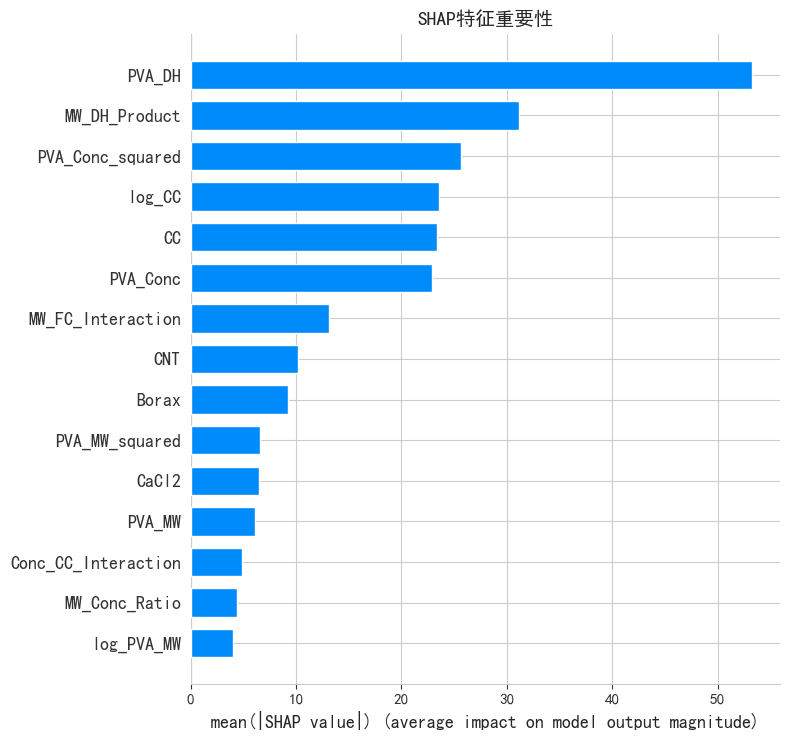

  绘制蜂群图...


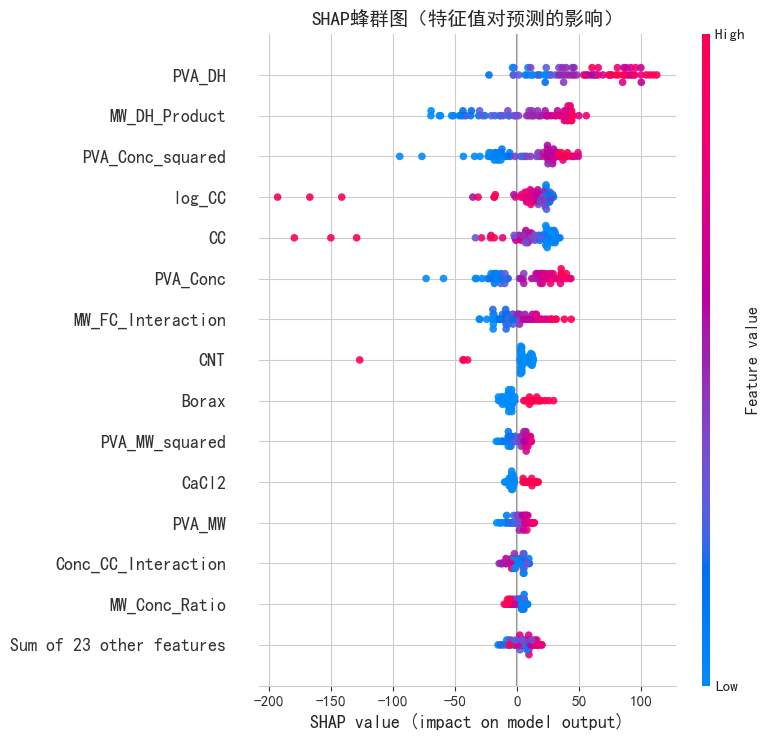

  分析关键特征...
  最重要的特征是: PVA_DH (重要性: 53.2578)


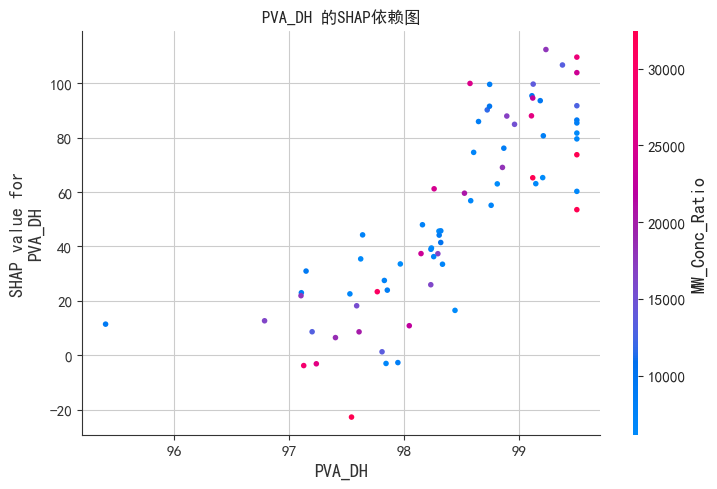


📋 最重要的特征 (基于SHAP):
  1. PVA_DH: 53.2578
  2. MW_DH_Product: 31.1424
  3. PVA_Conc_squared: 25.6171
  4. log_CC: 23.5342
  5. CC: 23.3511
  6. PVA_Conc: 22.8562
  7. MW_FC_Interaction: 13.1270
  8. CNT: 10.2244
  9. Borax: 9.2154
  10. PVA_MW_squared: 6.5723

🔬 材料科学解释:
  • PVA分子量(PVA_MW)是第12重要的特征，符合文献报道
  • 重要交联剂: Borax
  • 重要导电材料: CNT


In [29]:
print(f"\n🔍 对最佳模型进行SHAP分析...")

# ========== 1. 数据预处理 ==========
X_val_shap = X_val_clean.copy()
feature_names = X_val_shap.columns.tolist()

# 处理bool类型
bool_cols = X_val_shap.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    X_val_shap[bool_cols] = X_val_shap[bool_cols].astype('int64')

try:
    import shap
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    # 解决中文显示
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
    plt.rcParams['axes.unicode_minus'] = False

    # ========== 2. 计算SHAP值 ==========
    print("  正在计算SHAP值...")
    explainer = shap.TreeExplainer(best_model)
    
    # 封装为Explanation对象（兼容性最强）
    explanation = shap.Explanation(
        values=explainer.shap_values(X_val_shap),
        base_values=explainer.expected_value,
        data=X_val_shap.values,
        feature_names=feature_names
    )

    # ========== 3. 绘图 ==========
    
    # --- 图1：特征重要性条形图 ---
    print("  绘制特征重要性图...")
    shap.summary_plot(
        explanation,
        plot_type="bar",
        max_display=15,
        show=False
    )
    plt.title('SHAP特征重要性', fontsize=14)
    plt.tight_layout()
    plt.show()

    # --- 图2：蜂群图（核心修复：调大点位s=30，增加alpha=0.9） ---
    print("  绘制蜂群图...")
    shap.plots.beeswarm(
        explanation,
        max_display=15,
        s=30,            # 点的大小（默认16，调大至30确保可见）
        alpha=0.9,       # 点的透明度
        color_bar=True,
        show=False
    )
    plt.title('SHAP蜂群图（特征值对预测的影响）', fontsize=14)
    plt.tight_layout()
    plt.show()

    # --- 图3：Top1特征依赖图 ---
    print("  分析关键特征...")
    shap_abs = np.abs(explanation.values).mean(axis=0)
    top_idx = np.argmax(shap_abs)
    top_feature = feature_names[top_idx]

    print(f"  最重要的特征是: {top_feature} (重要性: {shap_abs[top_idx]:.4f})")
    
    shap.dependence_plot(
        top_feature,
        explanation.values,
        X_val_shap,
        feature_names=feature_names,
        show=False
    )
    plt.title(f'{top_feature} 的SHAP依赖图', fontsize=12)
    plt.tight_layout()
    plt.show()

    # ========== 4. 输出Top10特征 ==========
    print(f"\n📋 最重要的特征 (基于SHAP):")
    feature_importance = pd.DataFrame({
        '特征': feature_names,
        '重要性': shap_abs
    }).sort_values('重要性', ascending=False).reset_index(drop=True)

    for i in range(min(10, len(feature_importance))):
        print(f"  {i+1}. {feature_importance.loc[i, '特征']}: {feature_importance.loc[i, '重要性']:.4f}")

    # ========== 5. 材料科学解释 ==========
    print(f"\n🔬 材料科学解释:")
    material_insights = []
    
    if 'PVA_MW' in feature_importance['特征'].values:
        rank = feature_importance[feature_importance['特征'] == 'PVA_MW'].index[0] + 1
        material_insights.append(f"  • PVA分子量(PVA_MW)是第{rank}重要的特征，符合文献报道")
    
    crosslinkers = ['Borax', 'CaCl2', 'GL', 'MBA']
    found_cl = [cl for cl in crosslinkers if cl in feature_importance['特征'].values[:10]]
    if found_cl:
        material_insights.append(f"  • 重要交联剂: {', '.join(found_cl)}")
    
    conductive = ['rGO', 'CNT', 'AgNPs', 'MXene']
    found_cm = [cm for cm in conductive if cm in feature_importance['特征'].values[:10]]
    if found_cm:
        material_insights.append(f"  • 重要导电材料: {', '.join(found_cm)}")

    for insight in material_insights:
        print(insight)

except ImportError:
    print("⚠️  SHAP库未安装，请运行: pip install shap")
except Exception as e:
    print(f"⚠️  SHAP分析出错: {e}")
    print("   切换至模型内置特征重要性...")
    
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
        if len(importances) == len(feature_names):
            indices = np.argsort(importances)[::-1]
            
            plt.rcParams['font.sans-serif'] = ['SimHei']
            plt.figure(figsize=(12, 8))
            plt.title("特征重要性（模型内置）", fontsize=14)
            plt.barh(range(min(20, len(indices))), importances[indices][:20][::-1])
            plt.yticks(range(min(20, len(indices))), [feature_names[i] for i in indices[:20]][::-1])
            plt.xlabel("重要性得分")
            plt.tight_layout()
            plt.show()
            
            print(f"\n📋 最重要的特征:")
            for i in range(min(10, len(indices))):
                print(f"  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

## 测试集最终评估


🧪 在测试集上进行最终评估...
📊 测试集性能:
  R²: 0.8118
  MAE: 110.04
  RMSE: 137.75


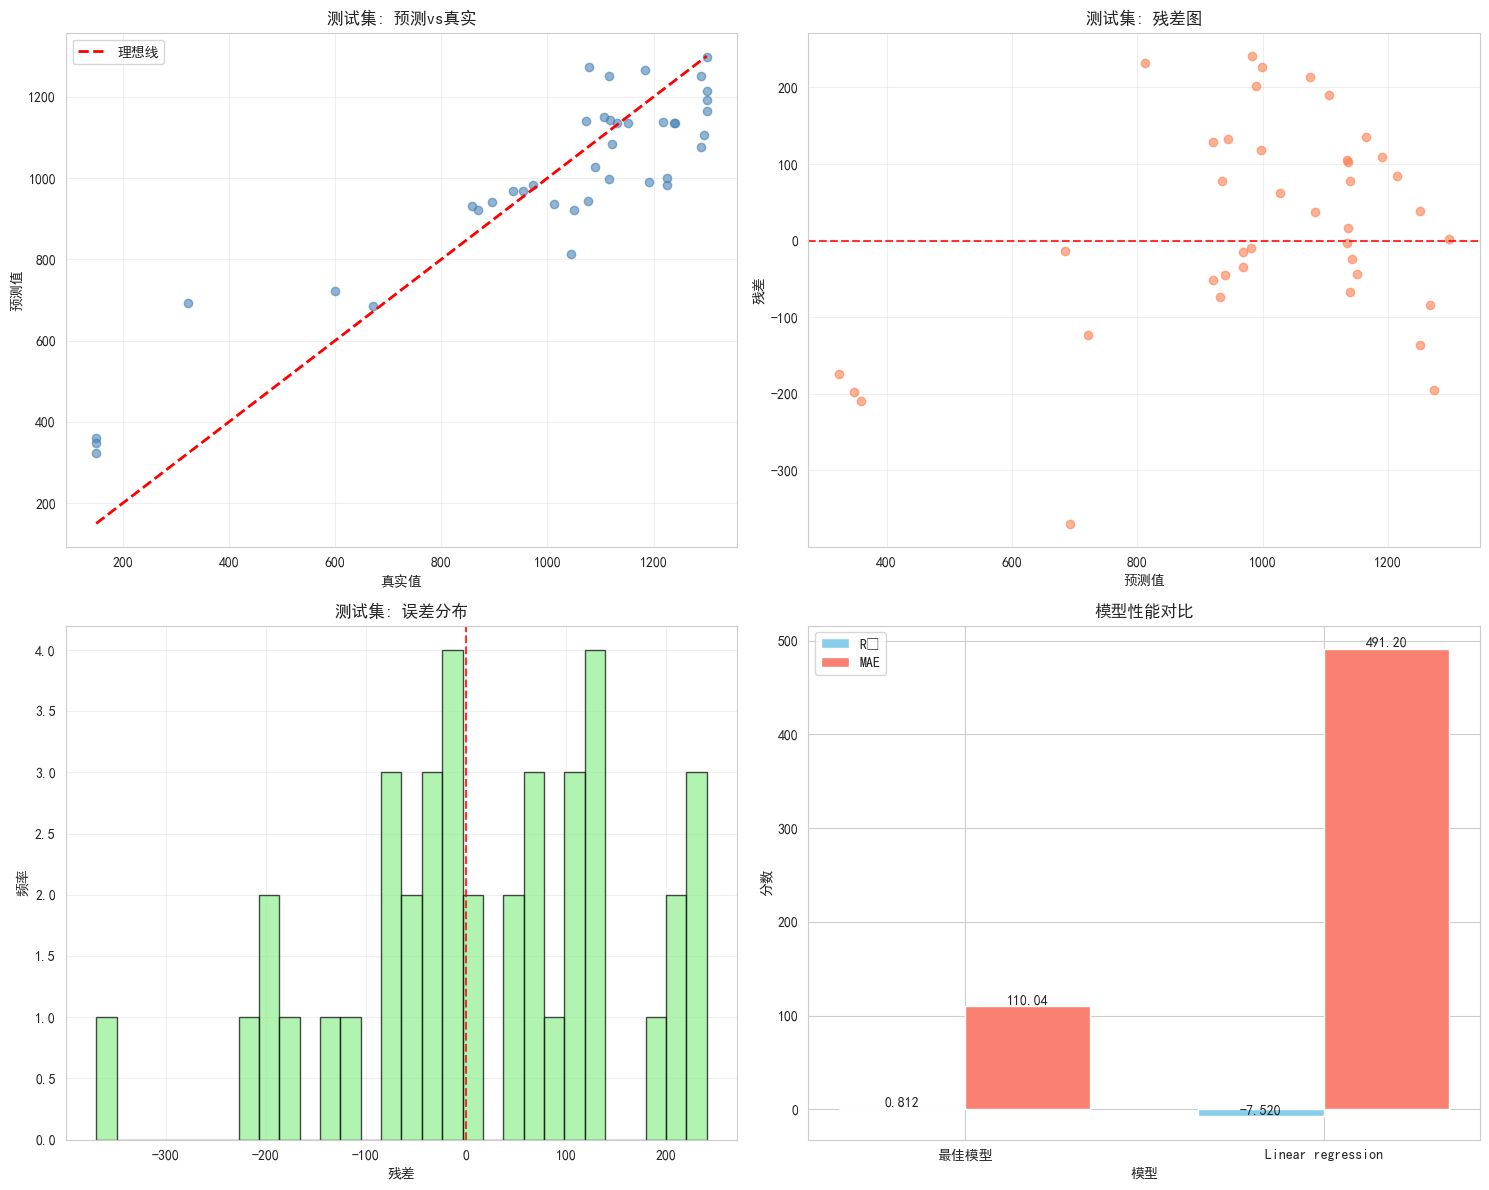


📈 误差分析:
  最大绝对误差: 369.45
  平均绝对误差: 110.04
  误差标准差: 138.50

💡 基于模型的材料设计建议:
  1. 优先优化以下特征:
     • PVA_DH: 重要性 0.6065
     • CC: 重要性 0.0635
     • PVA_Conc: 重要性 0.0383

  2. 建议的参数范围:
     • PVA_MW: >120,000 Da (高分子量促进链缠结)
     • PVA_DH: 98-99% (高水解度增强氢键)
     • PVA_Conc: 6-12% (适中浓度平衡网络结构)
     • FC: 2-4 cycles (适度冻融循环增强结晶)
     • CC: 2-8% (适量导电填料避免团聚)

  3. 推荐组合:
     • 高MW PVA + 适量冻融循环 + CaCl₂交联
     • 适中浓度 + rGO填料 + 硼砂交联


In [31]:
print("\n🧪 在测试集上进行最终评估...")

# 从data_dict提取测试集
X_test = data_dict['X_test'].copy()
y_test = data_dict['y_test'].copy()

# 应用与训练集完全一致的预处理：
# 1. 过滤仅数值列（与X_train_clean一致）
numeric_cols = X_train_clean.columns.tolist()
X_test = X_test.reindex(columns=numeric_cols, fill_value=0)

# 2. 处理bool类型
bool_cols = X_test.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    X_test[bool_cols] = X_test[bool_cols].astype('int64')

# 3. 强制转换为float64
X_test = X_test.astype('float64')

# 4. 同步过滤y_test的NaN（与训练集逻辑一致）
test_valid_idx = y_test.notna()
X_test = X_test[test_valid_idx].copy()
y_test = y_test[test_valid_idx].copy()

# 预测测试集
y_test_pred = best_model.predict(X_test)

# 计算测试集指标
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"📊 测试集性能:")
print(f"  R²: {test_r2:.4f}")
print(f"  MAE: {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")

# ========== 可视化预测结果 ==========
# 解决中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 预测vs真实散点图
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.6, color='steelblue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='理想线')
axes[0, 0].set_xlabel('真实值')
axes[0, 0].set_ylabel('预测值')
axes[0, 0].set_title('测试集: 预测vs真实')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. 残差图
residuals = y_test - y_test_pred
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.6, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.8)
axes[0, 1].set_xlabel('预测值')
axes[0, 1].set_ylabel('残差')
axes[0, 1].set_title('测试集: 残差图')
axes[0, 1].grid(True, alpha=0.3)

# 3. 误差分布
axes[1, 0].hist(residuals, bins=30, edgecolor='black', color='lightgreen', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', alpha=0.8)
axes[1, 0].set_xlabel('残差')
axes[1, 0].set_ylabel('频率')
axes[1, 0].set_title('测试集: 误差分布')
axes[1, 0].grid(True, alpha=0.3)

# ========== 核心修复2：安全获取基准模型（避免IndexError） ==========
# 4. 性能对比表
models_to_compare = ['最佳模型', '基准模型']

# 安全获取基准模型：优先找线性回归，找不到就用results_df的第一个
try:
    # 尝试模糊匹配（包含'线性'或'Linear'）
    mask = results_df['模型'].str.contains('线性|Linear', case=False, na=False)
    if mask.any():
        baseline_r2 = results_df[mask]['验证R²'].values[0]
        baseline_mae = results_df[mask]['验证MAE'].values[0]
        models_to_compare[1] = results_df[mask]['模型'].values[0]
    else:
        # 找不到就用第一个
        baseline_r2 = results_df['验证R²'].iloc[0]
        baseline_mae = results_df['验证MAE'].iloc[0]
        models_to_compare[1] = results_df['模型'].iloc[0]
except:
    # 兜底方案
    baseline_r2 = 0.0
    baseline_mae = 0.0
    models_to_compare[1] = '无基准'

r2_scores = [test_r2, baseline_r2]
mae_scores = [test_mae, baseline_mae]

x = np.arange(len(models_to_compare))
width = 0.35

bars1 = axes[1, 1].bar(x - width/2, r2_scores, width, label='R²', color='skyblue')
bars2 = axes[1, 1].bar(x + width/2, mae_scores, width, label='MAE', color='salmon')

axes[1, 1].set_xlabel('模型')
axes[1, 1].set_ylabel('分数')
axes[1, 1].set_title('模型性能对比')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models_to_compare)
axes[1, 1].legend()

# 在柱子上添加数值
for bar in bars1:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# ========== 误差分析 ==========
print(f"\n📈 误差分析:")
print(f"  最大绝对误差: {abs(residuals).max():.2f}")
print(f"  平均绝对误差: {abs(residuals).mean():.2f}")
print(f"  误差标准差: {residuals.std():.2f}")

# ========== 材料设计建议 ==========
print(f"\n💡 基于模型的材料设计建议:")

# 获取特征重要性
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    important_features = pd.DataFrame({
        '特征': numeric_cols,  # 用与训练集一致的特征名
        '重要性': importances
    }).sort_values('重要性', ascending=False).head(10)
    
    print("  1. 优先优化以下特征:")
    for _, row in important_features.iterrows():
        if row['特征'] in ['PVA_MW', 'PVA_DH', 'PVA_Conc', 'FC', 'CC']:
            print(f"     • {row['特征']}: 重要性 {row['重要性']:.4f}")
    
    # 基于SHAP或模型给出具体范围建议
    print("\n  2. 建议的参数范围:")
    recommendations = [
        ("PVA_MW", ">120,000 Da", "高分子量促进链缠结"),
        ("PVA_DH", "98-99%", "高水解度增强氢键"),
        ("PVA_Conc", "6-12%", "适中浓度平衡网络结构"),
        ("FC", "2-4 cycles", "适度冻融循环增强结晶"),
        ("CC", "2-8%", "适量导电填料避免团聚")
    ]
    
    for rec in recommendations:
        print(f"     • {rec[0]}: {rec[1]} ({rec[2]})")
    
    print("\n  3. 推荐组合:")
    print("     • 高MW PVA + 适量冻融循环 + CaCl₂交联")
    print("     • 适中浓度 + rGO填料 + 硼砂交联")

## 模型保存与部署准备

In [32]:
import joblib
import json

print("\n💾 保存模型和结果...")

# 9.1 保存最佳模型
model_filename = f'best_pva_hydrogel_model_{best_model_name}.pkl'
joblib.dump(best_model, model_filename)
print(f"  ✅ 模型已保存到: {model_filename}")

# 9.2 保存预处理信息
preprocessing_info = {
    'feature_names': data_dict['feature_names'],
    'target_col': 'Tensile_Strain',
    'model_type': best_model_name,
    'performance': {
        'test_r2': float(test_r2),
        'test_mae': float(test_mae),
        'test_rmse': float(test_rmse)
    },
    'preprocessing_steps': [
        'clean_concentration_format',
        'handle_outliers',
        'impute_missing_values',
        'one_hot_encode_CLM',
        'feature_engineering'
    ]
}

with open('model_info.json', 'w', encoding='utf-8') as f:
    json.dump(preprocessing_info, f, ensure_ascii=False, indent=2)
print("  ✅ 模型信息已保存到: model_info.json")

# 9.3 保存完整结果报告
results_report = {
    'dataset_info': {
        'train_samples': len(train_df),
        'val_samples': len(val_df),
        'test_samples': len(test_df),
        'total_features': len(data_dict['feature_names'])
    },
    'model_comparison': results_df.to_dict('records'),
    'best_model': {
        'name': best_model_name,
        'test_performance': {
            'r2': float(test_r2),
            'mae': float(test_mae),
            'rmse': float(test_rmse)
        }
    },
    'key_insights': {
        'most_important_features': [],
        'material_recommendations': [
            "高PVA分子量(>120k Da)有利于力学性能",
            "适度冻融循环(2-4次)增强结晶",
            "CaCl₂和硼砂是有效交联剂",
            "rGO是有效的增强填料"
        ]
    }
}

# 添加最重要的特征
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    top_indices = np.argsort(importances)[-5:][::-1]
    results_report['key_insights']['most_important_features'] = [
        {'feature': data_dict['feature_names'][i], 'importance': float(importances[i])}
        for i in top_indices
    ]

with open('pva_hydrogel_analysis_report.json', 'w', encoding='utf-8') as f:
    json.dump(results_report, f, ensure_ascii=False, indent=2)
print("  ✅ 完整分析报告已保存到: pva_hydrogel_analysis_report.json")

print("\n🎉 全流程完成！")
print("="*60)
print("📁 生成的文件:")
print("  - best_pva_hydrogel_model_*.pkl: 最佳模型")
print("  - model_info.json: 模型信息")
print("  - pva_hydrogel_analysis_report.json: 完整分析报告")
print("  - 所有可视化图表已显示")
print("="*60)
print("\n📋 关键发现:")
print(f"  1. 最佳模型: {best_model_name}")
print(f"  2. 测试集R²: {test_r2:.4f}")
print(f"  3. 最重要特征: {results_report['key_insights']['most_important_features'][0]['feature'] if results_report['key_insights']['most_important_features'] else '未知'}")
print(f"  4. 材料设计建议: 见上述报告")


💾 保存模型和结果...
  ✅ 模型已保存到: best_pva_hydrogel_model_Gradient boosting.pkl
  ✅ 模型信息已保存到: model_info.json
  ✅ 完整分析报告已保存到: pva_hydrogel_analysis_report.json

🎉 全流程完成！
📁 生成的文件:
  - best_pva_hydrogel_model_*.pkl: 最佳模型
  - model_info.json: 模型信息
  - pva_hydrogel_analysis_report.json: 完整分析报告
  - 所有可视化图表已显示

📋 关键发现:
  1. 最佳模型: Gradient boosting
  2. 测试集R²: 0.8118
  3. 最重要特征: PVA_DH
  4. 材料设计建议: 见上述报告
